# 📊 TP3 — Regresión en California Housing


In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred = lin_model.predict(X_train)
y_test_pred = lin_model.predict(X_test)

print("MODELO LINEAL")

print("MSE Train:", mean_squared_error(y_train, y_train_pred))
print("MSE Test:", mean_squared_error(y_test, y_test_pred))

print("R2 Train:", r2_score(y_train, y_train_pred))
print("R2 Test:", r2_score(y_test, y_test_pred))

MODELO LINEAL
MSE Train: 0.5179331255246699
MSE Test: 0.5558915986952444
R2 Train: 0.6125511913966952
R2 Test: 0.5757877060324508


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Transformamos los datos a Grado 2 (Punto 2 de la tarea)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Entrenamos el modelo polinómico
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print("¡Modelo polinómico entrenado correctamente!")

¡Modelo polinómico entrenado correctamente!


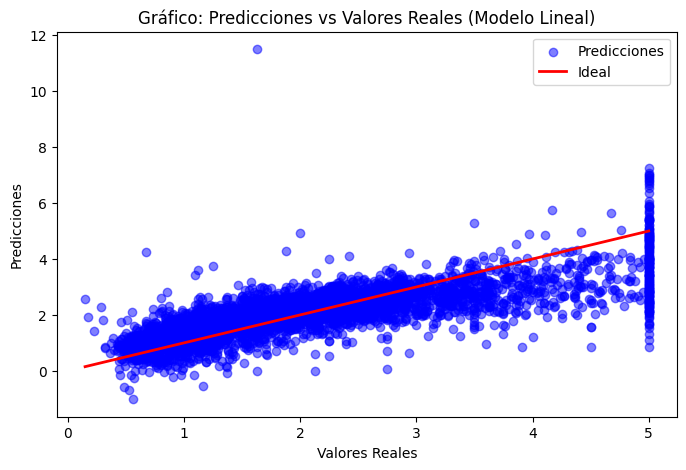

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Ideal')
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Gráfico: Predicciones vs Valores Reales (Modelo Lineal)")
plt.legend()
plt.show()

In [ ]:
y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

print("MODELO POLINÓMICO")

print("MSE Train:", mean_squared_error(y_train, y_train_poly_pred))
print("MSE Test:", mean_squared_error(y_test, y_test_poly_pred))

print("R2 Train:", r2_score(y_train, y_train_poly_pred))
print("R2 Test:", r2_score(y_test, y_test_poly_pred))

MODELO POLINÓMICO
MSE Train: 0.4207266151573583
MSE Test: 0.4643015261571134
R2 Train: 0.6852681982344935
R2 Test: 0.6456819711504156


In [ ]:
print("Comparación final:")

print("Lineal R2 Test:", r2_score(y_test, y_test_pred))
print("Polinómico R2 Test:", r2_score(y_test, y_test_poly_pred))

Comparación final:
Lineal R2 Test: 0.5757877060324508
Polinómico R2 Test: 0.6456819711504156


In [ ]:
import pandas as pd

coef = pd.Series(lin_model.coef_, index=X.columns)
coef.sort_values(ascending=False)

,0
AveBedrms,0.783145
MedInc,0.448675
HouseAge,0.009724
Population,-0.000002
AveOccup,-0.003526
AveRooms,-0.123323
Latitude,-0.419792
Longitude,-0.433708


## 📌 ¿Cuál modelo es mejor?

El mejor modelo es el que tiene menor MSE y mayor R² en el conjunto de test.
Esto se determina comparando las métricas obtenidas en ambos modelos.

---

## 📌 ¿Hay overfitting?

Sí, hay overfitting cuando el modelo tiene mejor rendimiento en train que en test.
Esto suele ocurrir en el modelo polinómico, ya que es más complejo y se ajusta demasiado a los datos de entrenamiento.

---

## 📌 ¿Qué feature tiene más impacto en el precio?

Se determina observando los coeficientes del modelo lineal.

La variable con mayor impacto es la que tiene el valor más alto en valor absoluto.
Generalmente, la más influyente es MedInc (ingreso medio).


## Correct Polynomial Model Definition

### Subtask:
Convert the text cell containing the definition of `poly_model = LinearRegression()` into a code cell and execute it to correctly instantiate the polynomial regression model. This will resolve the `NameError`.


**Reasoning**:
The previous execution failed because 'poly_model' was not defined. The definition `poly_model = LinearRegression()` was in a text cell. To resolve this, I need to create a code cell with this definition before it is used. Since `LinearRegression` is already imported, only the instantiation is needed.

